In [1]:
print("hello")

hello


## 1. Project Overview

This project analyzes an online marketplace dataset to understand sales patterns, 
revenue distribution, pricing behavior, and product demand trends.

The goal is to extract meaningful business insights using:
- Pandas for data manipulation
- NumPy for numerical operations
- Matplotlib for visualization

This analysis simulates real-world marketplace behavior similar to product exchange platforms.

Dataset Link:https://www.kaggle.com/datasets/lakshmi25npathi/online-retail-dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

## 2. Data Loading


In [21]:
url="OnlineRetail.xlsx"
df = pd.read_excel(url)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 3. Initial Data Exploration

In [22]:
print("Shape of dataset:", df.shape)

Shape of dataset: (541909, 8)


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [24]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [25]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## 4. Data Cleaning

Steps performed:
- Removed missing CustomerID
- Removed duplicate rows
- Removed negative quantities (returns)
- Converted date column to datetime

In [26]:
df = df.dropna(subset=["CustomerID"])
df = df.drop_duplicates()
df = df[df["Quantity"] > 0]
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

## 5. Feature Engineering

Created new columns:
- TotalPrice (Revenue)
- Month
- PriceCategory

In [27]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]
df["Month"] = df["InvoiceDate"].dt.month

df["PriceCategory"] = np.where(
    df["UnitPrice"] > df["UnitPrice"].median(),
    "High Price",
    "Low Price"
)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Month,PriceCategory
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12,High Price
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,High Price
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12,High Price
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,High Price
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,High Price


## 6. Analysis 1: Which Countries Generate the Highest Revenue?

In [28]:
country_revenue = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False)
country_revenue.head(10)

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalPrice, dtype: float64

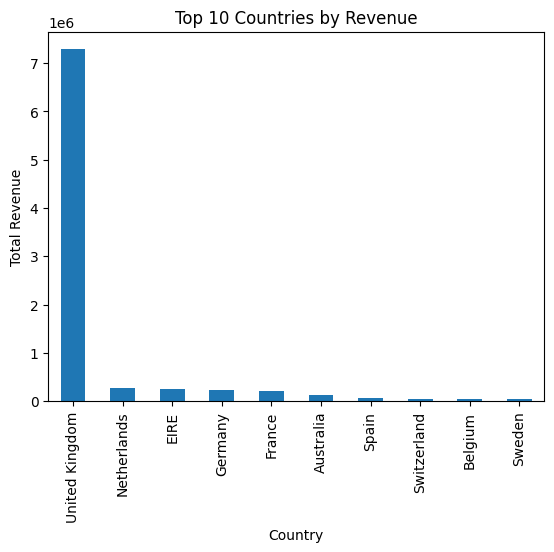

In [29]:
plt.figure()
country_revenue.head(10).plot(kind="bar")
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Total Revenue")
plt.show()

### Insight:
The top contributing countries generate significantly higher revenue, 
indicating strong customer demand in these regions.

## 7. Analysis 2: Relationship Between Price and Quantity

In [ ]:
correlation = df["UnitPrice"].corr(df["Quantity"])
print("Correlation:", correlation)

Correlation: -0.004576781205087342


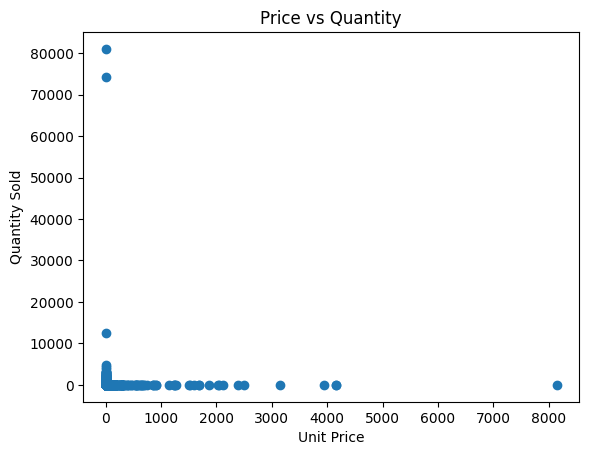

In [ ]:
plt.figure()
plt.scatter(df["UnitPrice"], df["Quantity"])
plt.title("Quantity VS Price ")
plt.xlabel("Unit Price")
plt.ylabel("Quantity Sold")
plt.show()

### Insight:
The correlation indicates whether higher prices reduce demand.
A negative correlation suggests higher prices reduce quantity sold.

## 8. Analysis 3: Monthly Revenue Trend

In [ ]:
monthly_revenue = df.groupby("Month")["TotalPrice"].sum()
monthly_revenue

Month
1      568101.310
2      446084.920
3      594081.760
4      468374.331
5      677355.150
6      660046.050
7      598962.901
8      644051.040
9      950690.202
10    1035642.450
11    1156205.610
12    1087613.170
Name: TotalPrice, dtype: float64

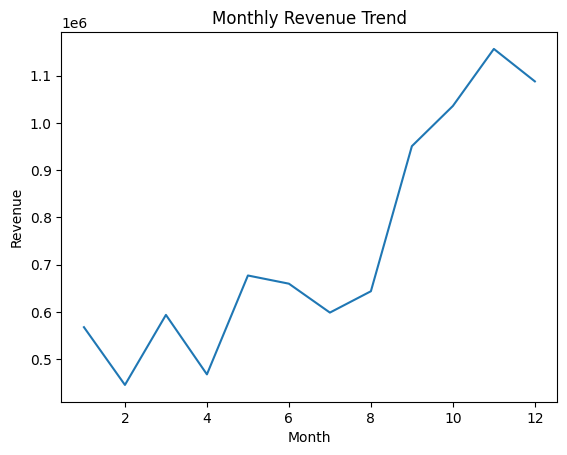

In [ ]:
plt.figure()
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

## 9. Revenue by Price Category

In [ ]:
price_group = df.groupby("PriceCategory")["TotalPrice"].sum()
price_group

PriceCategory
High Price    5272852.310
Low Price     3614356.584
Name: TotalPrice, dtype: float64

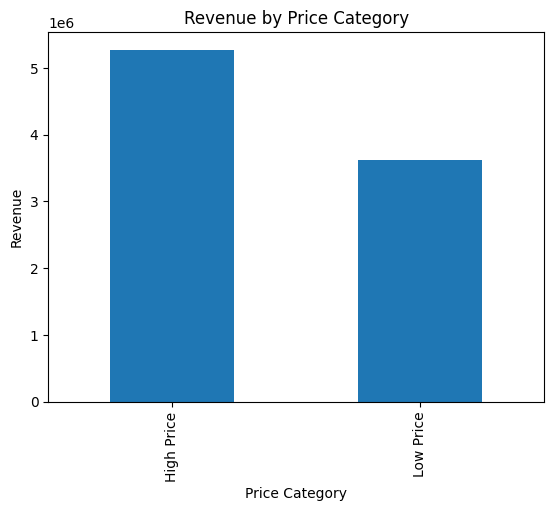

In [ ]:
plt.figure()
price_group.plot(kind="bar")
plt.title("Revenue by Price Category")
plt.xlabel("Price Category")
plt.ylabel("Revenue")
plt.show()

## 10. Outlier Detection in Unit Price

In [ ]:
mean_price = np.mean(df["UnitPrice"])
std_price = np.std(df["UnitPrice"])

z_scores = np.abs((df["UnitPrice"] - mean_price) / std_price)
outliers = df[z_scores > 3]

print("Number of Outliers:", outliers.shape[0])

Number of Outliers: 221


### Insight:
Outliers represent extremely high-priced products or bulk transactions.

## 11. Most Popular Products

In [ ]:
top_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)
top_products

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

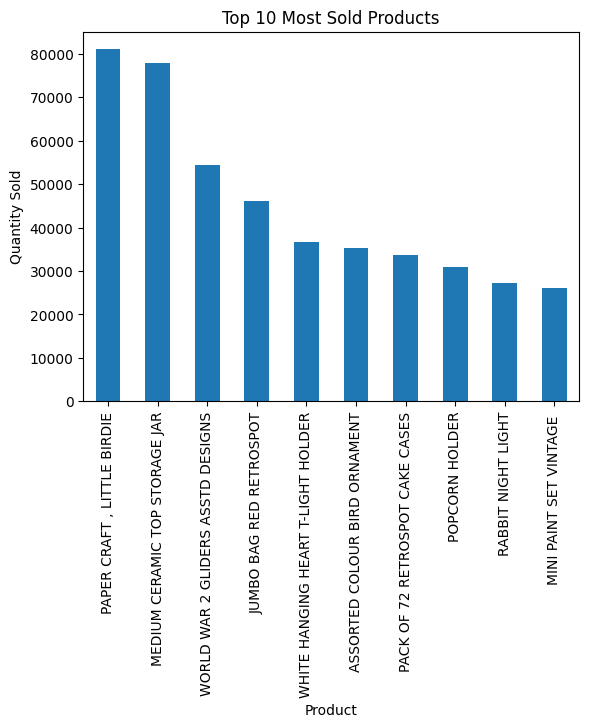

In [ ]:
plt.figure()
top_products.plot(kind="bar")
plt.title("Top 10 Most Sold Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.show()

## 12. Key Findings

1. A small number of countries contribute majority of total revenue.
2. There is a slight negative relationship between price and quantity.
3. Revenue shows seasonal trends.
4. High-price products contribute large revenue per transaction.
5. A small number of products dominate total sales volume.

## 13. Limitations

- Dataset limited to specific time period.
- Customer demographic details are not available.
- Correlation does not imply causation.
- External market factors are not considered.

## 14. Conclusion

This project demonstrates how data analysis techniques using Pandas and NumPy 
can reveal meaningful business insights in a marketplace environment.

The analysis provides understanding of:
- Revenue distribution
- Pricing behavior
- Customer demand
- Seasonal sales patterns

Such analysis can support business decision-making in real-world marketplace systems.